In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler


In [17]:
x = np.arange(1, 101, 1)
y_train = 3 * x ** 2 - 6 * x ** np.e
X_train = np.c_[x, x ** 2, x ** 3]
X_feature = ['$x$', '$x^2$', '$x^3$']

Peak to Peak range by column in Raw        X: [    99   9999 999999]
Peak to Peak range by column in Normalised X: [3.42963208 3.32281438 3.47378146]


Text(0, 0.5, 'y')

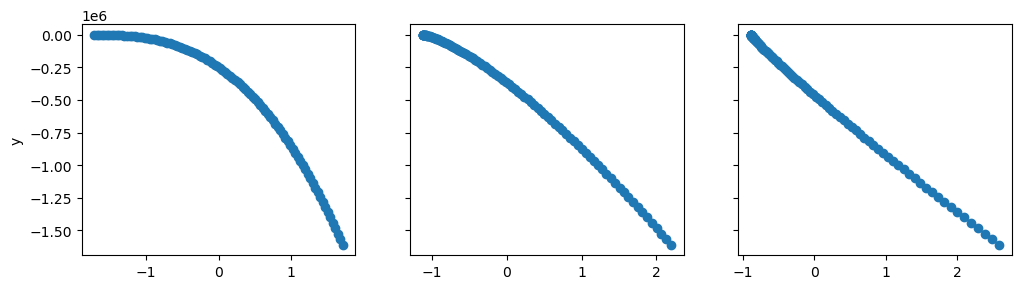

In [10]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)

print(f'Peak to Peak range by column in Raw        X: {np.ptp(X_train, axis=0)}')
print(f'Peak to Peak range by column in Normalised X: {np.ptp(X_norm, axis=0)}')

fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_norm[:, i], y_train)

ax[0].set_ylabel("y")

In [11]:
sgdr = SGDRegressor(max_iter=10000)
sgdr.fit(X_norm, y_train)
print(sgdr)
print(f'number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}')

SGDRegressor(max_iter=10000)
number of iterations completed: 1269, number of weight updates: 126901.0


In [12]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters: w: {w_norm}, b: {b_norm}")

model parameters: w: [  29942.68168551 -181719.40711203 -317893.42801427], b: [-439017.65668383]


In [13]:
y_pred_sgd = sgdr.predict(X_norm)
y_pred = X_norm @ w_norm + b_norm
print(f"prediction using np.dot() and sgdr.predict math: {(y_pred == y_pred_sgd).all()}")
print(f"Prediction on training set: \n{y_pred[:4]}")

prediction using np.dot() and sgdr.predict math: True
Prediction on training set: 
[-4480.03376392 -3631.6311057  -2917.25601761 -2343.53426008]


Text(0.5, 0.98, 'target versus perdiction using z-score normalised model')

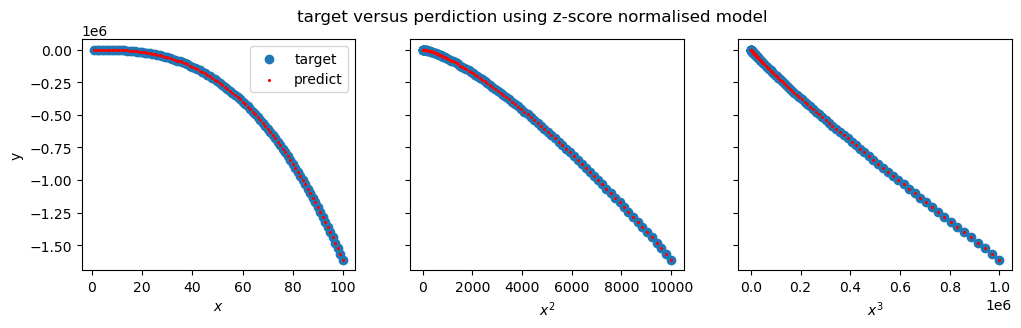

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i], y_train, label='target')
    ax[i].set_xlabel(X_feature[i])
    ax[i].scatter(X_train[:,i], y_pred, color='r', label='predict', marker='.', s=6)

ax[0].set_ylabel("y")
ax[0].legend()
fig.suptitle("target versus perdiction using z-score normalised model")
